# Transcription probability, ordered — new sim cohort

Recreation of the two-panel figure from `notebooks/older_notebooks/nora_figures_recover.ipynb`
(cell 87), against the new simulation cohort in `New_outputs/`
(run `20260706.223256__subgen_paper_sims_1`). No `/Volumes/mcovert` dependency.

Two framings, same visual language:

| | Panel set A | Panel set B |
|---|---|---|
| source | `transcription_prob_subgen.tsv` | `subgenerational_expression_table_def5.tsv` |
| y | `prob_mRNA_exists_in_gen` — fraction of generations in which the mRNA was **present** | `p_any_synth_def4` — fraction of generations with ≥1 **completed** transcript |
| x | rank by `actual_rna_synth_prob` | rank by `def5_CI_mean` |
| color | `y == 1` / `y == 0` / else | `def5_CI_category` |
| n | 4345 cistrons | 4309 genes |

**A** is the direct recreation of Nora's figure — the new TSV has exactly the columns the
original code expected, so that block runs essentially unchanged. **B** renders this run's own
canonical definition (see `New_outputs/analysis_scripts_README.xlsx`), which is built on
*completed* transcripts rather than mRNA presence, in the same style so the two can be compared.

`prob_mRNA_exists_in_gen` is not a copy of any `def_N` column — the closest is `p_present_def1`
(max abs difference 0.007). The two panels measure genuinely different things.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("white")


def find_repo_dir(name):
    # Walk up from the cwd until a directory containing `name` is found.
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / name).is_dir():
            return candidate / name
    raise FileNotFoundError(f"could not locate {name}/ above {here}")


NEW_OUTPUTS = find_repo_dir("New_outputs")
FIG_DIR = NEW_OUTPUTS.parent / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("data  ->", NEW_OUTPUTS)
print("figs  ->", FIG_DIR)

data  -> /Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/New_outputs
figs  -> /Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/notebooks/figures


## Constants

Carried forward verbatim from `nora_figures_recover.ipynb` (cells 6, 66, 81, 82).

In [2]:
palette_colors = {
    'never_expressed': 'lightcoral',
    'subgen': 'mediumseagreen',
    'always_expressed': 'skyblue',
}

# def5 adds a fourth category; the three shared ones keep the original colors.
def5_palette_colors = {
    'never_expressed': 'lightcoral',
    'subgen': 'mediumseagreen',
    'possibly_subgen': 'lightseagreen',
    'not_subgen': 'skyblue',
}
DEF5_CATEGORY_ORDER = ['never_expressed', 'subgen', 'possibly_subgen', 'not_subgen']

monomers_of_interest_name_dict = {
    'GLYCDEH-MONOMER[c]': 'gldA',
    'BETAGALACTOSID-MONOMER[c]': 'lacZ',
    'RIBULOKIN-MONOMER[c]': 'araB',
    'BAES-MONOMER[i]': 'baeS',
    'G6504-MONOMER[o]': 'gfcE',
    'EG11250-MONOMER[c]': 'chpS',
    'EG11222-MONOMER[c]': 'alkA',
    'G7263-MONOMER[c]': 'murQ',
    'EG11249-MONOMER[c]': 'mazF',
    'EG10466-MONOMER[c]': 'hupA',
}

monomer_cistron_dict = {
    'GLYCDEH-MONOMER[c]': 'EG11904_RNA',
    'BETAGALACTOSID-MONOMER[c]': 'EG10527_RNA',
    'RIBULOKIN-MONOMER[c]': 'EG10053_RNA',
    'BAES-MONOMER[i]': 'EG11617_RNA',
    'G6504-MONOMER[o]': 'G6504_RNA',
    'EG11250-MONOMER[c]': 'EG11250_RNA',
    'EG11222-MONOMER[c]': 'EG11222_RNA',
    'G7263-MONOMER[c]': 'G7263_RNA',
    'EG11249-MONOMER[c]': 'EG11249_RNA',
    'EG10466-MONOMER[c]': 'EG10466_RNA',
}

cistron_monomer_dict = {}
for key, values in monomer_cistron_dict.items():
    cistron_monomer_dict[values] = key

CURATED_CISTRONS = list(monomer_cistron_dict.values())


def gene_symbol(cistron_id):
    return monomers_of_interest_name_dict[cistron_monomer_dict[cistron_id]]

## Provenance

In [3]:
with open(NEW_OUTPUTS / 'subgen_raw_extract_run_metadata.json') as fh:
    run_meta = json.load(fh)

sim = run_meta['simulation']
print(f"description   : {sim['description']}")
print(f"run time      : {sim['run_time']}   variant: {sim['variant']}")
print(f"sim git       : {sim['git_branch']} @ {sim['git_hash'][:10]}")
print(f"generations   : {sim['total_gens']}  (burn-in "
      f"{run_meta['analysis']['parameters']['ignore_first_n_gens']})")
print(f"lineages      : {run_meta['lineages']['n_successful']} successful "
      f"/ {run_meta['lineages']['n_seeds']} seeds")
print(f"cells included: {run_meta['cells']['n_included']}")
print(f"genes         : {run_meta['genes']['n_genes']}")

description   : subgen_paper_sims_1
run time      : 20260706.223256   variant: wildtype
sim git       : subgen_monomer_aj @ c38d3abc4b
generations   : 32  (burn-in 8)
lineages      : 95 successful / 128 seeds
cells included: 2622
genes         : 4309


## Panel set A — faithful recreation

`prob_mRNA_exists_in_gen(g) = (# cells where the mRNA was present at any timestep) / n_cells`,
ranked by the time-averaged fractional synthesis probability.

In [4]:
prob_df = pd.read_csv(NEW_OUTPUTS / 'transcription_prob_subgen.tsv', sep='\t')
prob_df.sort_values(by='actual_rna_synth_prob', ascending=True, inplace=True)
prob_df.reset_index(drop=True, inplace=True)

missing = [c for c in CURATED_CISTRONS if c not in set(prob_df['mRNA_cistron_id'])]
print(f"n cistrons          : {len(prob_df)}")
print(f"prob == 0           : {(prob_df['prob_mRNA_exists_in_gen'] == 0).sum()}")
print(f"prob == 1           : {(prob_df['prob_mRNA_exists_in_gen'] == 1).sum()}")
print(f"curated genes missing: {missing if missing else 'none'}")
prob_df.head()

n cistrons          : 4345
prob == 0           : 171
prob == 1           : 856
curated genes missing: none


,mRNA_cistron_id,actual_rna_synth_prob,prob_mRNA_exists_in_gen
0,G0-17015_RNA,0.0,0.0
1,G0-16721_RNA,0.0,0.0
2,G0-16690_RNA,0.0,0.0
3,G0-16689_RNA,0.0,0.0
4,G0-16688_RNA,0.0,0.0


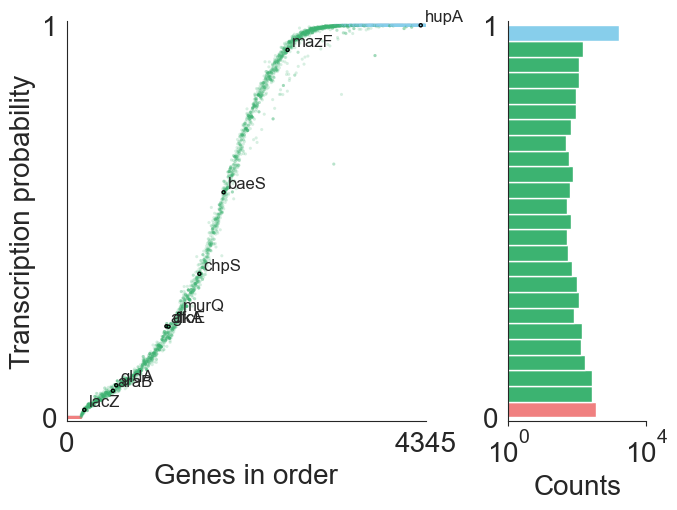

In [5]:
fig = plt.figure(figsize=(10, 5))
scatterAxis = plt.subplot2grid((2, 4), (0, 0), colspan=2, rowspan=2)
histAxis = plt.subplot2grid((2, 4), (0, 2), colspan=1, rowspan=2, sharey=scatterAxis)

colors = np.repeat('mediumseagreen', len(prob_df['prob_mRNA_exists_in_gen']))
colors[np.where(prob_df['prob_mRNA_exists_in_gen'] == 1)] = 'skyblue'
colors[np.where(prob_df['prob_mRNA_exists_in_gen'] == 0)] = 'lightcoral'

scatterAxis.scatter(prob_df.index,
                    prob_df['prob_mRNA_exists_in_gen'],
                    marker="o",
                    facecolors=colors, edgecolors="none", s=5, alpha=0.2)

highlight_df = prob_df[prob_df['mRNA_cistron_id'].isin(monomer_cistron_dict.values())]
h_colors = np.repeat('mediumseagreen', len(highlight_df['prob_mRNA_exists_in_gen']))
h_colors[np.where(highlight_df['prob_mRNA_exists_in_gen'] == 1)] = 'skyblue'
h_colors[np.where(highlight_df['prob_mRNA_exists_in_gen'] == 0)] = 'lightcoral'

scatterAxis.scatter(highlight_df.index,
                    highlight_df['prob_mRNA_exists_in_gen'],
                    marker="o", s=5, facecolors=h_colors, edgecolors='black',
                    label='Highlighted Points')

for cistron_id in highlight_df['mRNA_cistron_id'].unique():
    hit = highlight_df[highlight_df['mRNA_cistron_id'] == cistron_id]
    if hit.empty:
        print(f"skipping {cistron_id}: not in table")
        continue
    x_coor = hit.index[0]
    y_coor = hit['prob_mRNA_exists_in_gen'].iloc[0]
    scatterAxis.annotate(gene_symbol(cistron_id),
                         (x_coor, y_coor),
                         textcoords="offset points", xytext=(3, 3), ha='left', fontsize=12)

scatterAxis.set_xlim([0, len(prob_df['prob_mRNA_exists_in_gen'])])
scatterAxis.set_ylim([-.01, 1.01])
scatterAxis.spines['top'].set_visible(False)
scatterAxis.spines['right'].set_visible(False)
first_yloc = 0
last_yloc = 1
scatterAxis.set_yticks([first_yloc, last_yloc])
first_xloc = 0
hadTranscribedFrequency = prob_df['prob_mRNA_exists_in_gen']
last_xloc = np.arange(len(hadTranscribedFrequency))[-1]
scatterAxis.set_xticks([first_xloc, last_xloc + 1])
scatterAxis.tick_params(axis='x', labelsize=20)
scatterAxis.tick_params(axis='y', labelsize=20)
scatterAxis.set_ylabel('Transcription probability', fontsize=20)
scatterAxis.set_xlabel('Genes in order', fontsize=20)

N, bins, patches = histAxis.hist(hadTranscribedFrequency, bins=25, orientation='horizontal')
for i in range(1, len(patches) - 1):
    plt.setp(patches[i], facecolor='mediumseagreen', edgecolor='white')
plt.setp(patches[0], facecolor='lightcoral', edgecolor='white')
plt.setp(patches[-1], facecolor='skyblue', edgecolor='white')
histAxis.set_xscale('log', base=10)
histAxis.xaxis.tick_bottom()
histAxis.spines['top'].set_visible(False)
histAxis.spines['right'].set_visible(False)
# Ticks pinned to whole decades spanning the counts, rather than whatever
# get_xticks() happens to hold before the axis is drawn.
first_tick_val = 1.0
last_tick_val = 10 ** np.ceil(np.log10(max(N.max(), 10)))
histAxis.set_xlim(first_tick_val, last_tick_val)
histAxis.set_xticks([first_tick_val, last_tick_val])
histAxis.tick_params(axis='x', labelsize=20)
histAxis.tick_params(axis='y', labelsize=20)
histAxis.set_xlabel('Counts', fontsize=20)
plt.subplots_adjust(wspace=0.6, hspace=0.4, right=0.9, bottom=0.1, left=0.1, top=0.9)

plt.savefig(FIG_DIR / 'transcription_probability_ordered_new_sims.svg', transparent=True)
plt.show()

## Panel set B — def-5 canonical, same visual language

Same layout, but y is `p_any_synth_def4` (P[≥1 **completed** transcript per generation]),
x is the rank by `def5_CI_mean` (mean completed transcripts per generation), and points are
colored by `def5_CI_category` rather than by y. Because category is no longer a function of y,
the histogram is stacked by category instead of recoloring its first and last bins.

In [6]:
def5_df = pd.read_csv(NEW_OUTPUTS / 'subgenerational_expression_table_def5.tsv', sep='\t')
def5_df.sort_values(by='def5_CI_mean', ascending=True, inplace=True)
def5_df.reset_index(drop=True, inplace=True)

missing = [c for c in CURATED_CISTRONS if c not in set(def5_df['cistron_name'])]
print(f"n genes             : {len(def5_df)}")
print(f"curated genes missing: {missing if missing else 'none'}")
print(def5_df['def5_CI_category'].value_counts().to_string())
def5_df.head()

n genes             : 4309
curated genes missing: none
def5_CI_category
not_subgen         2263
subgen             1859
never_expressed     135
possibly_subgen      52


,gene_name,cistron_name,protein_name,monomer_name,def5_CI_category,def5_CI_mean,ci_lower,ci_upper,def5_pooled_mean,p_any_synth_def4,max_mRNA_count,max_protein_count
0,G0-10607,G0-10607_RNA,MONOMER0-2829,MONOMER0-2829[c],never_expressed,0.0,0.0,0.0,0.0,0.0,0,0
1,G0-17019,G0-17019_RNA,MONOMER0-4485,MONOMER0-4485[c],never_expressed,0.0,0.0,0.0,0.0,0.0,0,0
2,G0-17018,G0-17018_RNA,MONOMER0-4484,MONOMER0-4484[c],never_expressed,0.0,0.0,0.0,0.0,0.0,0,0
3,G0-17017,G0-17017_RNA,MONOMER0-4483,MONOMER0-4483[m],never_expressed,0.0,0.0,0.0,0.0,0.0,0,0
4,G0-17016,G0-17016_RNA,MONOMER0-4482,MONOMER0-4482[c],never_expressed,0.0,0.0,0.0,0.0,0.0,0,0


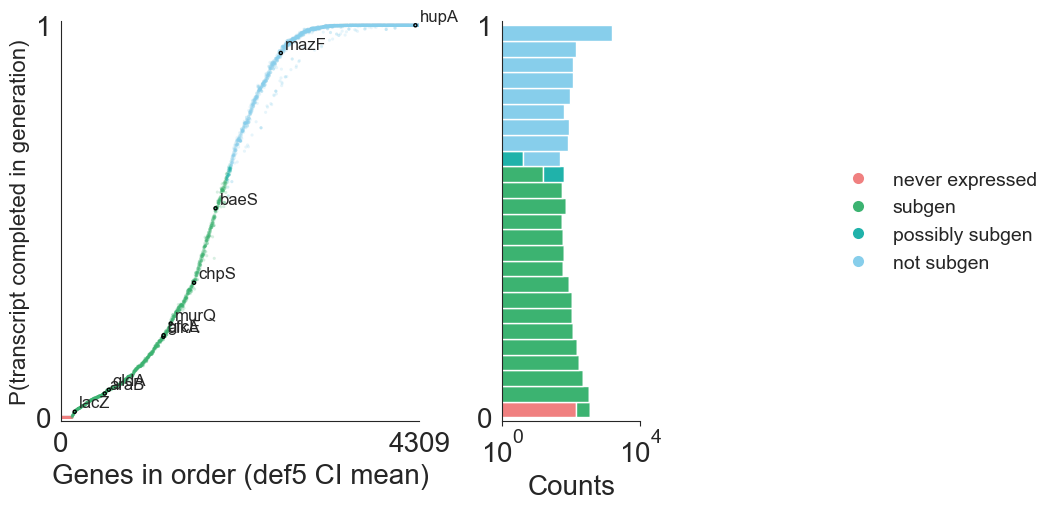

In [7]:
fig = plt.figure(figsize=(10, 5))
scatterAxis = plt.subplot2grid((2, 4), (0, 0), colspan=2, rowspan=2)
histAxis = plt.subplot2grid((2, 4), (0, 2), colspan=1, rowspan=2, sharey=scatterAxis)

colors = def5_df['def5_CI_category'].map(def5_palette_colors).to_numpy()

scatterAxis.scatter(def5_df.index,
                    def5_df['p_any_synth_def4'],
                    marker="o",
                    facecolors=colors, edgecolors="none", s=5, alpha=0.2)

highlight_df = def5_df[def5_df['cistron_name'].isin(monomer_cistron_dict.values())]
h_colors = highlight_df['def5_CI_category'].map(def5_palette_colors).to_numpy()

scatterAxis.scatter(highlight_df.index,
                    highlight_df['p_any_synth_def4'],
                    marker="o", s=5, facecolors=h_colors, edgecolors='black',
                    label='Highlighted Points')

for cistron_id in highlight_df['cistron_name'].unique():
    hit = highlight_df[highlight_df['cistron_name'] == cistron_id]
    if hit.empty:
        print(f"skipping {cistron_id}: not in table")
        continue
    x_coor = hit.index[0]
    y_coor = hit['p_any_synth_def4'].iloc[0]
    scatterAxis.annotate(gene_symbol(cistron_id),
                         (x_coor, y_coor),
                         textcoords="offset points", xytext=(3, 3), ha='left', fontsize=12)

scatterAxis.set_xlim([0, len(def5_df['p_any_synth_def4'])])
scatterAxis.set_ylim([-.01, 1.01])
scatterAxis.spines['top'].set_visible(False)
scatterAxis.spines['right'].set_visible(False)
scatterAxis.set_yticks([0, 1])
scatterAxis.set_xticks([0, len(def5_df)])
scatterAxis.tick_params(axis='x', labelsize=20)
scatterAxis.tick_params(axis='y', labelsize=20)
scatterAxis.set_ylabel('P(transcript completed in generation)', fontsize=16)
scatterAxis.set_xlabel('Genes in order (def5 CI mean)', fontsize=20)

stacked_values = [def5_df.loc[def5_df['def5_CI_category'] == cat, 'p_any_synth_def4'].to_numpy()
                  for cat in DEF5_CATEGORY_ORDER]
stacked_colors = [def5_palette_colors[cat] for cat in DEF5_CATEGORY_ORDER]
N, bins, patches = histAxis.hist(stacked_values, bins=25, stacked=True,
                                 orientation='horizontal',
                                 color=stacked_colors, edgecolor='white')
histAxis.set_xscale('log', base=10)
histAxis.xaxis.tick_bottom()
histAxis.spines['top'].set_visible(False)
histAxis.spines['right'].set_visible(False)
first_tick_val = 1.0
last_tick_val = 10 ** np.ceil(np.log10(max(np.asarray(N).max(), 10)))
histAxis.set_xlim(first_tick_val, last_tick_val)
histAxis.set_xticks([first_tick_val, last_tick_val])
histAxis.tick_params(axis='x', labelsize=20)
histAxis.tick_params(axis='y', labelsize=20)
histAxis.set_xlabel('Counts', fontsize=20)

handles = [plt.Line2D([], [], marker='o', linestyle='none', markersize=8,
                      markerfacecolor=def5_palette_colors[cat], markeredgecolor='none',
                      label=cat.replace('_', ' '))
           for cat in DEF5_CATEGORY_ORDER]
fig.legend(handles=handles, fontsize=14, frameon=False,
           loc='center left', bbox_to_anchor=(0.86, 0.5))

plt.subplots_adjust(wspace=0.6, hspace=0.4, right=0.9, bottom=0.1, left=0.1, top=0.9)

# bbox_inches='tight' so the outside legend is not clipped by the 10x5in canvas
# (panel set A has no legend and keeps the original's exact canvas).
plt.savefig(FIG_DIR / 'transcription_probability_ordered_def5.svg',
            transparent=True, bbox_inches='tight')
plt.show()

## A vs B for the curated genes

`prob_mRNA_exists_in_gen` (mRNA *present*) sits above `p_any_synth_def4` (transcript *completed*)
for essentially every gene — a generation can inherit an mRNA it never finished making.

In [8]:
compare = (
    prob_df.merge(def5_df, left_on='mRNA_cistron_id', right_on='cistron_name', how='left')
    .assign(gene=lambda d: d['mRNA_cistron_id'].map(
        lambda c: monomers_of_interest_name_dict.get(cistron_monomer_dict.get(c))))
)

curated = (
    compare[compare['mRNA_cistron_id'].isin(CURATED_CISTRONS)]
    [['gene', 'mRNA_cistron_id', 'actual_rna_synth_prob', 'prob_mRNA_exists_in_gen',
      'p_any_synth_def4', 'def5_CI_mean', 'def5_CI_category']]
    .sort_values('prob_mRNA_exists_in_gen')
    .reset_index(drop=True)
)
display(curated)

n_gap = compare['def5_CI_category'].isna().sum()
print(f"\ncistrons in transcription_prob_subgen.tsv but not in the def5 table: {n_gap}")
print("(all G0-*_RNA — cistrons with no associated monomer, so outside the def5 gene set)")

matched = compare.dropna(subset=['p_any_synth_def4'])
higher = (matched['prob_mRNA_exists_in_gen'] >= matched['p_any_synth_def4']).sum()
print(f"genes where P(mRNA present) >= P(transcript completed): {higher} / {len(matched)}")

,gene,mRNA_cistron_id,actual_rna_synth_prob,prob_mRNA_exists_in_gen,p_any_synth_def4,def5_CI_mean,def5_CI_category
0,lacZ,EG10527_RNA,7.552990e-08,0.019298,0.014474,0.014474,subgen
1,araB,EG10053_RNA,2.927024e-07,0.067982,0.060965,0.062719,subgen
2,gldA,EG11904_RNA,3.233880e-07,0.082018,0.070614,0.073246,subgen
3,gfcE,G6504_RNA,9.814559e-07,0.231579,0.209649,0.234211,subgen
4,alkA,EG11222_RNA,9.445299e-07,0.232456,0.205702,0.232456,subgen
5,murQ,G7263_RNA,1.247308e-06,0.264474,0.239474,0.272368,subgen
6,chpS,EG11250_RNA,1.839104e-06,0.366228,0.343421,0.425877,subgen
7,baeS,EG11617_RNA,3.378867e-06,0.574123,0.533333,0.753947,subgen
8,mazF,EG11249_RNA,1.236881e-05,0.937281,0.929386,2.732020,not_subgen
9,hupA,EG10466_RNA,8.091545e-04,1.000000,1.000000,177.533000,not_subgen



cistrons in transcription_prob_subgen.tsv but not in the def5 table: 36
(all G0-*_RNA — cistrons with no associated monomer, so outside the def5 gene set)
genes where P(mRNA present) >= P(transcript completed): 4257 / 4309
